In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("kidney_disease.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# ============================================
# REMOVE ID COLUMN
# ============================================

df.drop("id", axis=1, inplace=True)

# Replace missing symbols
df.replace("?", np.nan, inplace=True)

# Remove extra spaces
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
# ============================================
# MISSING VALUES
# ============================================

missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

rbc      152
rc       130
wc       105
pot       88
sod       87
pcv       70
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64

In [5]:
# ============================================
# ENCODE CATEGORICAL VARIABLES
# ============================================

df.replace({
    'normal': 0,
    'abnormal': 1,
    'present': 1,
    'notpresent': 0,
    'yes': 1,
    'no': 0,
    'good': 1,
    'poor': 0,
    'ckd': 1,
    'notckd': 0
}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_6464\712439555.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [6]:
# ============================================
# CONVERT TO NUMERIC
# ============================================

df = df.apply(pd.to_numeric, errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    float64
 6   pc              335 non-null    float64
 7   pcc             396 non-null    float64
 8   ba              396 non-null    float64
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [7]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

for col in df.columns:

    if df[col].nunique() <= 5:
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum().sum())

0


C:\Users\USER\AppData\Local\Temp\ipykernel_6464\1218451981.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_6464\1218451981.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

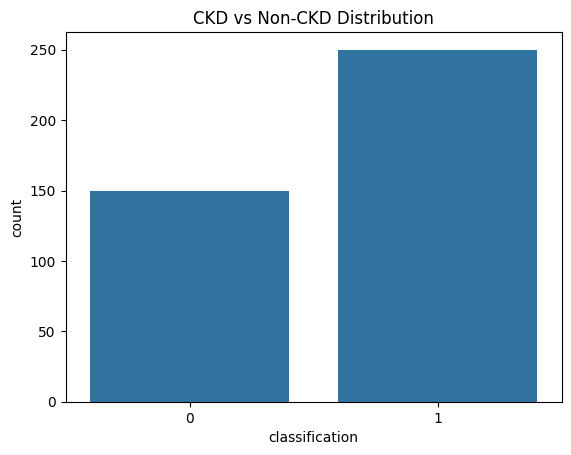

classification
1    250
0    150
Name: count, dtype: int64


In [8]:
# ============================================
# CLASS DISTRIBUTION
# ============================================

sns.countplot(x='classification', data=df)

plt.title("CKD vs Non-CKD Distribution")

plt.show()

print(df['classification'].value_counts())

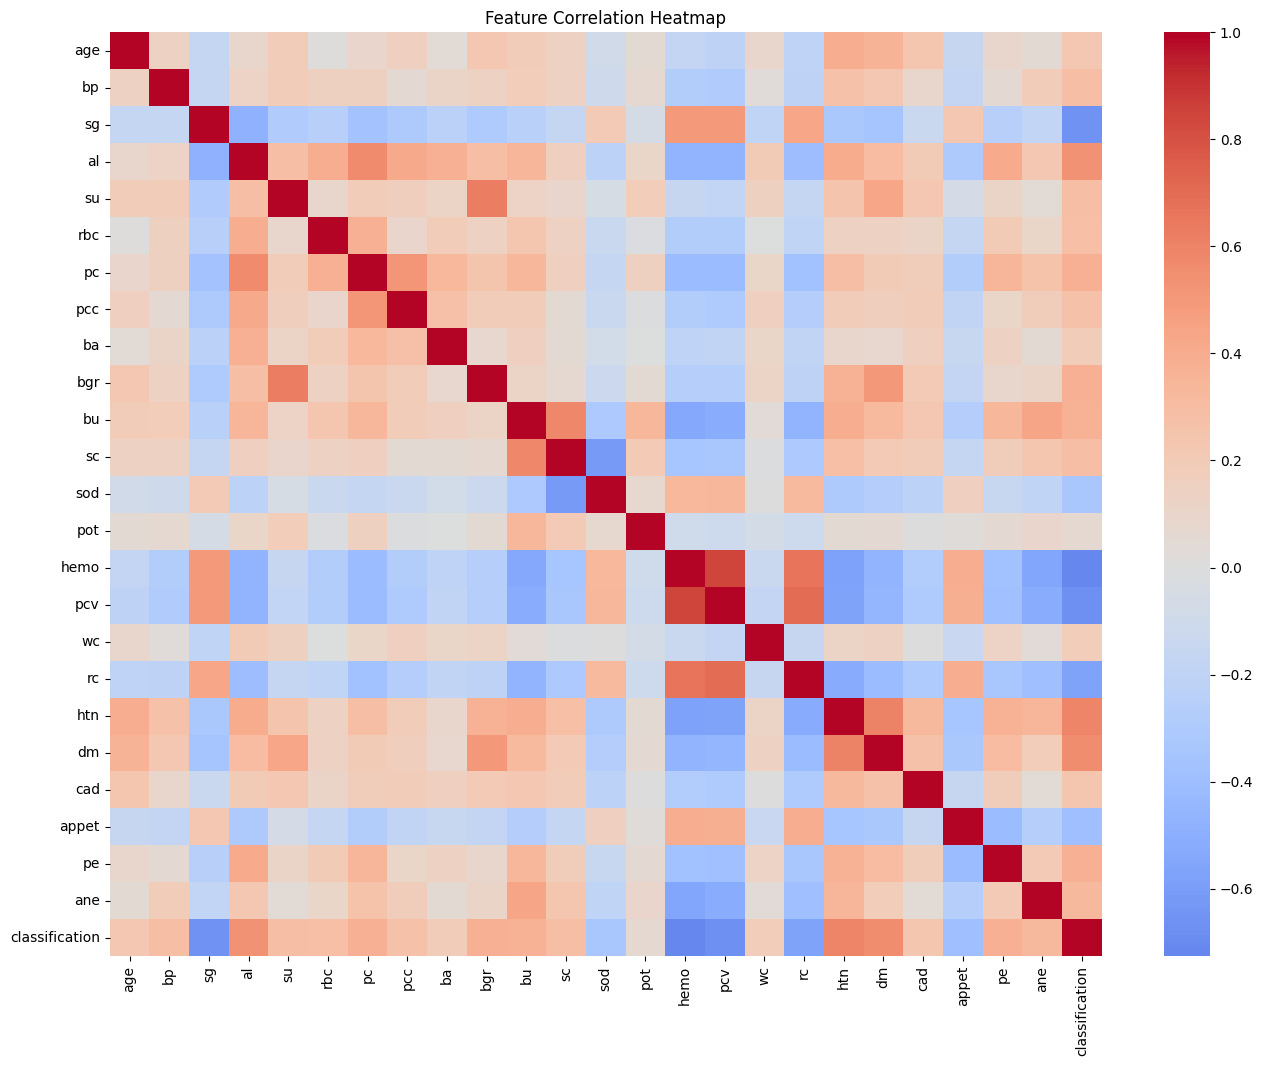

In [9]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [10]:
# ============================================
# FEATURE CORRELATION WITH CKD
# ============================================

corr_target = df.corr()['classification']

corr_target = corr_target.drop('classification')

corr_target = corr_target.sort_values(
    ascending=False
)

print(corr_target)

htn      0.590438
dm       0.559060
al       0.531562
bgr      0.379321
pc       0.375154
pe       0.375154
bu       0.369393
ane      0.325396
su       0.294555
bp       0.293693
sc       0.291245
rbc      0.282642
pcc      0.265313
cad      0.236088
age      0.227842
ba       0.186871
wc       0.177571
pot      0.065218
sod     -0.334900
appet   -0.393341
rc      -0.566163
sg      -0.659504
pcv     -0.673129
hemo    -0.726368
Name: classification, dtype: float64


In [11]:
# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop('classification', axis=1)
y = df['classification']

print(X.shape)
print(y.shape)

(400, 24)
(400,)


In [12]:
# ============================================
# STRATIFIED TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Distribution:")
print(y_train.value_counts())

print("\nTest Distribution:")
print(y_test.value_counts())

Train Shape: (320, 24)
Test Shape: (80, 24)

Train Distribution:
classification
1    200
0    120
Name: count, dtype: int64

Test Distribution:
classification
1    50
0    30
Name: count, dtype: int64


In [13]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(320, 24)


In [14]:
# ============================================
# BUILD IMPROVED ANN MODEL
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

ann_model = Sequential()

ann_model.add(
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001),
        input_shape=(24,)
    )
)

ann_model.add(
    Dropout(0.30)
)

ann_model.add(
    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

ann_model.add(
    Dropout(0.20)
)

ann_model.add(
    Dense(
        8,
        activation='relu'
    )
)

ann_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

ann_model.summary()

C:\Users\USER\anaconda3\envs\kidney_ann\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================
# COMPILE MODEL
# ============================================

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
# ============================================
# EARLY STOPPING
# ============================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [17]:
# ============================================
# TRAIN MODEL
# ============================================

history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6523 - loss: 0.6305 - val_accuracy: 0.7812 - val_loss: 0.5684
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7227 - loss: 0.5374 - val_accuracy: 0.8906 - val_loss: 0.4875
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8086 - loss: 0.4982 - val_accuracy: 0.9375 - val_loss: 0.4180
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8672 - loss: 0.4382 - val_accuracy: 0.9688 - val_loss: 0.3550
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3947 - val_accuracy: 0.9844 - val_loss: 0.2994
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - loss: 0.3441 - val_accuracy: 0.9844 - val_loss: 0.2505
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9258 - loss: 0.2804 - val_accuracy: 0.9844 - val_loss: 0.2066
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9297 - loss: 0.2622 - val_accuracy: 0.9844 - 

In [18]:
# ============================================
# PREDICTIONS
# ============================================

y_prob = ann_model.predict(X_test_scaled)

y_pred = (y_prob > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [19]:
# ============================================
# EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:

[[30  0]
 [ 0 50]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [20]:
# ============================================
# SENSITIVITY & SPECIFICITY
# ============================================

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Sensitivity: 1.0
Specificity: 1.0


In [21]:
# ============================================
# ROC AUC
# ============================================

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 1.0


In [22]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob.flatten()
})

results.sort_values(
    by="Probability",
    ascending=False
).head(20)

,Actual,Probability
1,1,1.0
7,1,1.0
11,1,1.0
36,1,1.0
38,1,1.0
37,1,1.0
44,1,1.0
40,1,1.0
32,1,1.0
33,1,1.0


In [23]:
results.sort_values(
    by="Probability",
    ascending=True
).head(20)

,Actual,Probability
70,0,0.000014
55,0,0.000018
6,0,0.000043
21,0,0.000050
35,0,0.000058
66,0,0.000059
49,0,0.000060
29,0,0.000085
0,0,0.000095
3,0,0.000212


In [24]:
# ============================================
# SAVE MODEL
# ============================================

ann_model.save("kidney_health_ann.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [25]:
# ============================================
# SAVE SCALER
# ============================================

import pickle

with open("kidney_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler Saved Successfully")

Scaler Saved Successfully
